# Data Analysis and Visualization

## Table of contents

| Jump | Topic |
|------|-------|
| [Part 1](#part1) | Hire your analyst team: the pipeline, agents, prompts, first look at the data. |
| [Part 2](#part2) | Descriptive statistics with AI: numbers, shape, groups, mean vs median. |
| [Part 3](#part3) | Plots and charts: matched chart types, honest visualization. |
| [Part 4](#part4) | Explaining results, verifying the AI's claims, ethics, take-away. |

## How to use this notebook

- Run cells **in order** with `Shift + Enter`. Markdown cells give the theory.
- Green boxes titled **Your turn: OpenCode** contain a ready-made prompt. Paste
  it into the assistant chat, wait for it to finish, then run the **checkpoint
  code cell** that verifies and analyzes the result.
- Every task has a deterministic fallback, so the course works fully offline.
- When you create or change agent `.md` files, **quit and restart OpenCode**
  (agent configuration is loaded once at startup).

**Tip for non-programmers:** you will see Python code, but the core skill is the
loop: *prompt -> run -> look -> improve*. Focus on that and on checking that what
the assistant says matches the numbers.

In [1]:
import os

# Make every relative path (data/..., AGENTS.md) resolve to THIS course folder,
# no matter where Jupyter started the kernel.
candidates = [os.getcwd(), "/home/jovyan/Data Analysis and Visualization"]
for path in candidates:
    if os.path.exists(os.path.join(path, "data/house_prices.csv")):
        os.chdir(path)
        break
print("Working directory:", os.getcwd())
print("Data present:", os.path.exists("data/house_prices.csv"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Working directory: /home/jovyan/Data Analysis and Visualization
Data present: True


<a id="part1"></a>

---

# Part 1 · Hire your analyst team

**Approximate time: 1 academic hour.**

## 1.1 Learning outcomes

After this part you will be able to:

- Name the four steps of the analysis pipeline.
- Explain what `AGENTS.md` and `.opencode/agent/*.md` do in an OpenCode project.
- Read a dataset with pandas and "feel" its shape before analyzing it.
- Write a good prompt using CATA plus a checkpoint, and verify the result.

## 1.2 The analysis pipeline

Analyzing data is rarely one jump. It is a loop of four steps:

1. **Collect** and **clean** the data so it is trustworthy (that was the sister
   course *Data Collection and Cleaning*).
2. **Describe** - get the numbers: how many rows, the mean, median, spread, and
   how things differ between groups (descriptive statistics).
3. **Visualize** - draw it: a picture reveals patterns a table hides.
4. **Explain** - write plain-language insights with evidence, and check them.

In this course you will do steps 2-4 on a clean dataset of 160 house sales
(`data/house_prices.csv`). You will do them twice: once with pandas/matplotlib
yourself, and once by **instructing an AI analyst team** - then you compare.

## 1.3 Your analyst team: agents as .md files

OpenCode lets you create specialist assistants, each as one Markdown file under
`.opencode/agent/`. This course ships a three-person "team":

| File | Role |
|------|------|
| `.opencode/agent/statistician.md` | Computes descriptive statistics and writes a report. |
| `.opencode/agent/chartist.md` | Makes matplotlib charts and saves PNGs. |
| `.opencode/agent/explainer.md` | Turns stats + charts into a plain-language insight report. |

Each file has **frontmatter** (`description`, `mode`, `model`, `temperature`,
`permissions`) and a **body** that is the agent's actual instructions. The
`AGENTS.md` file at the top of this folder is the team's "handbook": every
assistant reads it before working here.

> **Restart rule:** agent configuration is loaded when OpenCode starts. After you
> edit or add an `.md` agent file, **quit and restart OpenCode** for it to apply.

The next cell prints the `AGENTS.md` and the agent files that ship with this
course so you can read the rules the team must follow.

In [2]:
import os

path = "AGENTS.md"
if not os.path.exists(path):
    path = "/home/jovyan/Data Analysis and Visualization/AGENTS.md"

print(f"--- {path} ---")
with open(path, encoding="utf-8") as fh:
    print(fh.read())

--- AGENTS.md ---
# Data Analysis and Visualization - Agent Guide

This folder is the workspace for the academic course *Data Analysis and
Visualization*. It is a data-exploration project, not a software repository.

## Project layout

- `data/house_prices.csv` - the main (already clean) dataset students analyze.
- `scripts/` - Python scripts the notebook (or an agent) may generate.
- `data/plots/` - chart outputs (PNG) produced during the course.
- `data/reports/` - Markdown reports written by agents (descriptive stats, insights).

## Working rules for any assistant in this project

- The user is a learner, not an expert programmer: explain the *why* next to
  every change and keep code short, commented, and reproducible.
- Never modify `data/house_prices.csv`. Read it; write outputs to `data/plots/`
  or `data/reports/`.
- Never delete data or report files. Ask before destructive operations.
- Use a fixed `random.seed(...)` for anything generated so results are stable.
- Charts must 

In [3]:
import glob, os

print("Agent files in this project:\n")
for p in sorted(glob.glob(".opencode/agent/*.md")):
    with open(p, encoding="utf-8") as fh:
        text = fh.read()
    desc = next((ln.strip() for ln in text.splitlines()
                 if ln.startswith("description:")), "no description")
    print(f"- {p}\n    {desc}")
print("\nReusable command files:")
for p in sorted(glob.glob(".opencode/command/*.md")):
    print(f"- {p}")

Agent files in this project:

- .opencode/agent/chartist.md
    description: Creates matplotlib charts and saves them as PNG. Use when the user wants a histogram, boxplot, bar chart, scatter plot, or any visualization of a dataset.
- .opencode/agent/explainer.md
    description: Turns statistics and charts into a plain-language insight report. Use when the user wants results explained, an executive summary, or a narrative about the findings.
- .opencode/agent/statistician.md
    description: Computes descriptive statistics with pandas and writes a plain-language report. Use when the user wants summary statistics, mean/median/IQR, grouped stats, or a stats report.

Reusable command files:
- .opencode/command/describe.md
- .opencode/command/visualize.md


## 1.4 Meet the data before meeting the math

Good analysis starts with a **look**: how many rows and columns, what types the
columns have, which values appear, and are there any surprises. We do this before
any statistics - you cannot trust a number computed on data you have not looked
at. The cell below prints the first rows, a column summary, and simple counts.

In [4]:
df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape, "(rows, columns)\n")
print("--- First rows ---")
print(df.head().to_string(index=False))
print("\n--- Column info ---")
print(df.info())
print("\n--- How many of each city? ---")
print(df["city"].value_counts().to_string())

Shape: (160, 9) (rows, columns)

--- First rows ---
house_id      price  size_sqm  beds  baths  year_built      city  garage  rating
   H0001 16981404.0     196.9     4      4        2014 Amsterdam       0     4.3
   H0002  8332746.0     148.9     5      5        1998    Madrid       1     4.0
   H0003 10761936.0     173.8     3      3        2011    Madrid       1     4.4
   H0004  4872325.0      97.4     5      4        1995    Berlin       1     4.7
   H0005  7575478.0     104.5     2      3        2022    Madrid       1     4.2

--- Column info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_id    160 non-null    object 
 1   price       160 non-null    float64
 2   size_sqm    160 non-null    float64
 3   beds        160 non-null    int64  
 4   baths       160 non-null    int64  
 5   year_built  160 non-null    int64  
 6   city

<div style="background:#eff7e6;border-left:5px solid #4caf50;padding:10px 14px;">

**Your turn: OpenCode - create your own analyst**

Lets practise configuring an agent, exactly the skill this course builds on.
Paste into the chat:

> Context: course "Data Analysis and Visualization". I want to practise
> configuring an OpenCode agent as an `.md` file.
> Action: create `.opencode/agent/my-explorer.md` with frontmatter `description`,
> `mode: subagent`, `temperature: 0.2`, and a body that instructs the agent to
> (1) always look at `df.head()`, `df.info()` and `df.describe()` before saying
> anything, (2) answer only with evidence that code can reproduce, and (3) keep
> answers short and beginner-friendly. Save the file.
> Tone: clear, short instructions.
> Checkpoint: print the full file content.

When finished, **restart OpenCode** so the new agent loads, then run the
checkpoint below.

</div>

In [5]:
import os

path = ".opencode/agent/my-explorer.md"
if os.path.exists(path):
    print(f"--- {path} ---")
    print(open(path, encoding="utf-8").read()[:1200])
    print("\nCheckpoint: file exists. Does it have frontmatter and the")
    print("'look before you speak' rule?")
else:
    print("my-explorer.md not created yet (task optional).")
    print("You can skip or come back later - the built-in agents demonstrate")
    print("the same ideas.")

my-explorer.md not created yet (task optional).
You can skip or come back later - the built-in agents demonstrate
the same ideas.


## 1.5 Prompt anatomy (a one-minute recap)

A prompt is instructions to an agent. Use **CATA**:

- **C**ontext - project + what you have (which file, which step).
- **A**ction - one clear task, with the exact output file/format asked for.
- **T**one - "short", "beginner-friendly", "keep code commented".
- **A**nticipate - edge cases ("never edit the source CSV", "no evidence, no claim").

Plus a **checkpoint** - tell the agent *what you will verify* afterwards. A good
prompt is testable: you can check whether it worked. In the next parts you will
see exactly this pattern applied to statistics, charts, and explanations.

## 1.6 Part 1 - key takeaways

- Analysis pipeline: clean -> describe -> visualize -> explain.
- `AGENTS.md` = project rules; `.opencode/agent/*.md` = specialist agents.
- Agent changes need an **OpenCode restart**.
- **Look at data first**: shape, types, counts - a number on unseen data is a guess.
- A prompt = CATA + a checkpoint you can verify.

**Self-check (think, then continue):**
1. What are the four steps of the pipeline?
2. Why do we "look at the data" before computing statistics?
3. What must you do after editing an agent `.md` file?

---
In **Part 2** you will compute descriptive statistics yourself, then ask the
statistician agent to do it too - and compare.

<a id="part2"></a>

---

# Part 2 · Descriptive statistics with AI

**Approximate time: 1 academic hour.**

## 2.1 Learning outcomes

After this part you will be able to:

- Describe a numeric column with **count, mean, median, min/max, standard deviation**.
- Say why a **skewed** column makes the median safer than the mean.
- Compare groups with `groupby` (e.g. mean price per city).
- Ask the statistician agent for a report and **verify one number yourself**.

## 2.2 The vocabulary of numbers

Descriptive statistics answer "what does the data look like?" with a few numbers:

- **Count** - how many valid values we have.
- **Mean** - the average: sum divided by count. Sensitive to extreme values.
- **Median** - the middle value when sorted. Robust to extremes.
- **Min / Max** - the range of values.
- **Standard deviation (std)** - how spread out the values are around the mean.

A distribution is **skewed** when most values pile up on one side and a long
tail runs the other way (like house prices: a few extremely expensive homes pull
the mean up). Rule of thumb:

> If **mean > median**, the data has a heavy tail on the high side. The median
> is usually the better "typical" price to quote.

`df.describe()` gives all of this at once. `df.groupby(...)` repeats a summary
per group, so you can compare cities.

Let's compute these for our dataset.

In [6]:
# Full descriptive statistics for every numeric column, in one command.
describe = df.describe()
print(describe.to_string())

# The skew "tell": if mean > median, the tail is on the high side.
price_mean = df["price"].mean()
price_median = df["price"].median()
print(f"\nprice: mean={price_mean:,.0f}  median={price_median:,.0f}")
print("skewed to the high side?", "yes (median is the safer 'typical')" if price_mean > price_median else "no")

              price    size_sqm        beds      baths   year_built      garage      rating
count  1.600000e+02  160.000000  160.000000  160.00000   160.000000  160.000000  160.000000
mean   9.398716e+06  145.050625    3.075000    3.59375  2010.125000    0.812500    4.191250
std    3.222796e+06   31.337236    1.215984    1.47216     8.754334    0.391538    0.455903
min    3.606690e+06   51.400000    1.000000    1.00000  1995.000000    0.000000    3.100000
25%    7.115864e+06  119.725000    2.000000    2.00000  2002.000000    1.000000    3.900000
50%    9.161174e+06  149.700000    3.000000    4.00000  2010.500000    1.000000    4.300000
75%    1.122266e+07  167.525000    4.000000    5.00000  2018.250000    1.000000    4.600000
max    2.107569e+07  221.500000    5.000000    6.00000  2024.000000    1.000000    4.900000

price: mean=9,398,716  median=9,161,174
skewed to the high side? yes (median is the safer 'typical')


In [7]:
# Compare groups: mean and median price per city (this is a groupby summary).
grouped = df.groupby("city")["price"].agg(["count", "mean", "median", "std"])
print(grouped.to_string())
print("\nThe group with the highest median price:")
print(grouped["median"].idxmax(), "=", f"{grouped['median'].max():,.0f}")

           count          mean      median           std
city                                                    
Amsterdam     37  9.264832e+06   9061981.0  2.666100e+06
Berlin        40  8.975529e+06   8985683.0  2.530784e+06
London        44  1.161650e+07  11338727.0  3.682466e+06
Madrid        39  7.457655e+06   7200212.0  2.244700e+06

The group with the highest median price:
London = 11,338,727


### Reading what you just computed

- **Price is skewed** (mean > median), so the median is the more honest "typical price".
- **Cities differ**: the grouped table lets us say which city is pricier *on average*, backed by numbers.
- **Count matters**: a group with 20 houses is a weak claim; one with 60 is stronger.

Now let the Statistician agent produce its own report, then check that its
numbers match yours.

### Cheat sheet: statistics one-liners

| Goal | Code |
|------|------|
| Full numeric summary | `df.describe()` |
| Mean / median per group | `df.groupby("city")["price"].median()` |
| How many per category | `df["city"].value_counts()` |
| Missing values | `df.isna().sum()` |
| Correlation of two numbers | `df[["price", "size_sqm"]].corr()` |
| Skew tell | `df["price"].mean()` vs `df["price"].median()` |

These small pieces are all you need - the agent can draft them, and your
checkpoint confirms the numbers.

<div style="background:#eff7e6;border-left:5px solid #4caf50;padding:10px 14px;">

**Your turn: OpenCode - run the statistician**

Paste into the chat (CATA + checkpoint):

> Context: course "Data Analysis and Visualization". I have a clean dataset at
> `data/house_prices.csv` (160 rows). I already computed `describe()` and a
> groupby by `city` myself.
> Action: use the `statistician` agent from `.opencode/agent/statistician.md`.
> Compute descriptive statistics for every numeric column, say which ones are
> skewed and why (mean vs median), and add a grouped summary by `city`. Save the
> report to `data/reports/descriptive_stats.md`.
> Tone: beginner-friendly; define each term the first time you use it.
> Checkpoint: tell me the file path, the mean and median of `price`, and whether
> price is skewed - with the two numbers as evidence.

**Quick alternative:** after restarting OpenCode, type `/describe file=data/house_prices.csv group=city`
in the chat - it runs the same agent. Then run the checkpoint below.

</div>

In [8]:
import os

report = "data/reports/descriptive_stats.md"
if os.path.exists(report):
    print(f"--- agent report: {report} ---\n")
    print(open(report, encoding="utf-8").read()[:2200])
else:
    print("descriptive_stats.md not found yet (task optional).")
    print("The numbers are here, computed by you in the cells above:")
    print(f"  price mean  = {df['price'].mean():,.0f}")
    print(f"  price median= {df['price'].median():,.0f}")
    print("Run the task, then compare: a good report's numbers must match.")

descriptive_stats.md not found yet (task optional).
The numbers are here, computed by you in the cells above:
  price mean  = 9,398,716
  price median= 9,161,174
Run the task, then compare: a good report's numbers must match.


### Results analysis: trust the report only after checking it

A stats report is a list of *claims with numbers*. Three quick habits:

1. **Reproduce one number** - the checkpoint above does exactly this: it has
   the mean/median you computed yourself, so you can compare with the agent's.
2. **Check units and definitions** - is that "mean" a mean, or a median? Are
   prices in the same currency/unit as yours?
3. **Ask what is missing** - did the report mention sample sizes per city and
   outliers? A silent report is as dangerous as a wrong number.

## 2.3 Part 2 - key takeaways

- `describe()` gives count, mean, median, min/max, std in one call.
- **Skewed data -> median**, not mean, for a "typical" value.
- `groupby` compares groups; always report group **counts** too.
- Agents are great at drafting reports; **your checkpoints confirm the numbers**.

**Self-check (think, then continue):**
1. mean = 10, median = 6 - what does that tell you about the distribution?
2. Why is the median more robust to outliers than the mean?
3. What is the first thing you do after an agent hands you a stats report?

---
In **Part 3** you will see the numbers: histograms, boxplots, bar and scatter
charts - how to choose them and how to draw them honestly.

<a id="part3"></a>

---

# Part 3 · Plots and charts

**Approximate time: 1 academic hour.**

## 3.1 Learning outcomes

After this part you will be able to:

- Pick the right chart for the question (histogram, boxplot, bar, scatter).
- Explain what each chart shows and how to read it.
- Spot a **misleading chart** (truncated axis, missing labels, bad scale).
- Ask the chartist agent for charts, then **verify they exist and match reality**.

## 3.2 Why draw it? And which chart when?

A table of 160 prices is hard to grasp. A good chart is a picture of the same
numbers - patterns jump out. Match the chart to the question:

| I want to see... | Use |
|------------------|-----|
| shape/distribution of one number | **Histogram** (bins of equal width) |
| spread + outliers, by group | **Boxplot** (median, IQR, whiskers, points) |
| counts per category | **Bar chart** |
| relationship between two numbers | **Scatter plot** (one dot per row) |
| change over time | **Line chart** |

Two honesty rules for every chart: **label the axes with units**, and **never
truncate the y-axis** to exaggerate differences.

The plotting library here is **matplotlib**. The next cell builds four small
charts on our dataset and saves them as PNGs under `data/plots/`.

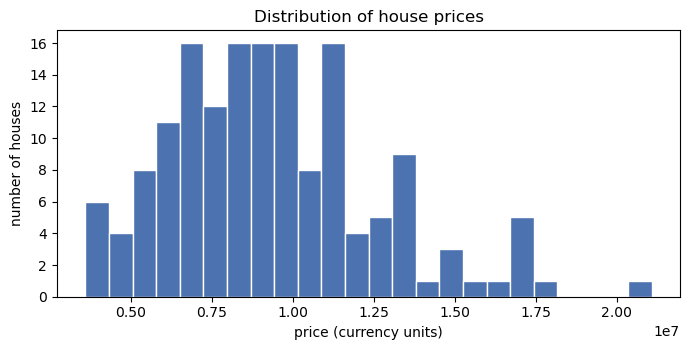

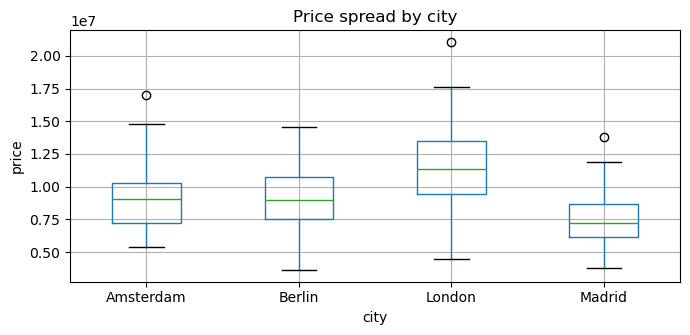

In [9]:
import os
os.makedirs("data/plots", exist_ok=True)

# 1) Histogram of price: shows the shape / skew.
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(df["price"], bins=24, color="#4c72b0", edgecolor="white")
ax.set_title("Distribution of house prices")
ax.set_xlabel("price (currency units)")
ax.set_ylabel("number of houses")
plt.tight_layout(); plt.savefig("data/plots/price_histogram.png"); plt.show()

# 2) Boxplot of price per city: spread + outliers by group.
fig, ax = plt.subplots(figsize=(7, 3.6))
df.boxplot(column="price", by="city", ax=ax)
ax.set_title("Price spread by city")
ax.set_xlabel("city"); ax.set_ylabel("price")
plt.suptitle(""); plt.tight_layout()
plt.savefig("data/plots/price_by_city_box.png"); plt.show()

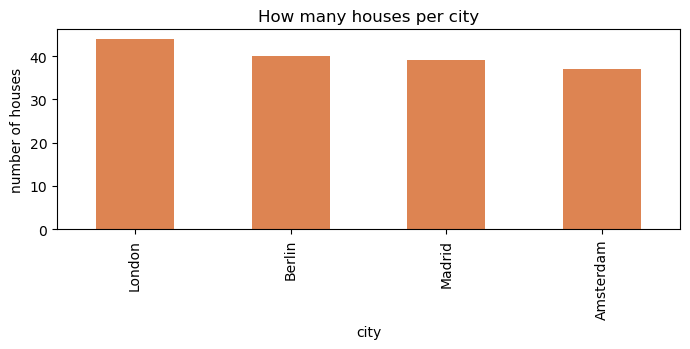

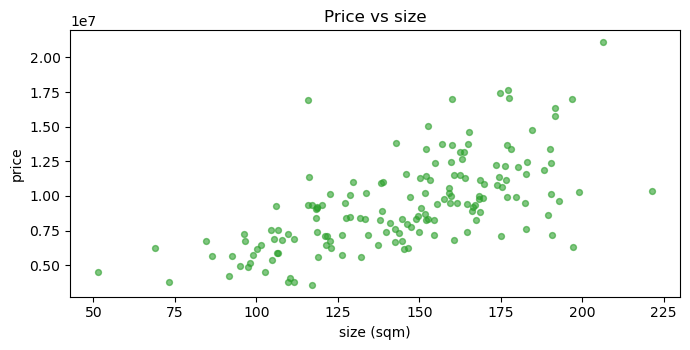

Saved 4 charts to data/plots/


In [10]:
# 3) Bar chart of how many houses per city (counts).
counts = df["city"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.6))
counts.plot(kind="bar", ax=ax, color="#dd8452")
ax.set_title("How many houses per city")
ax.set_xlabel("city"); ax.set_ylabel("number of houses")
plt.tight_layout(); plt.savefig("data/plots/city_counts_bar.png"); plt.show()

# 4) Scatter of price vs size: does a relationship show?
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(df["size_sqm"], df["price"], s=18, alpha=0.6, color="#2ca02c")
ax.set_title("Price vs size")
ax.set_xlabel("size (sqm)")
ax.set_ylabel("price")
plt.tight_layout(); plt.savefig("data/plots/price_size_scatter.png"); plt.show()

print("Saved 4 charts to data/plots/")

### Reading each chart

- **Histogram** - most houses are in a middle band; the long thin tail on the right is the skew we saw in Part 2 (a few very expensive homes).
- **Boxplot** - the box is the middle 50% of each city; the line inside is the median; dots beyond the whiskers are outliers.
- **Bar chart** - compares *counts*; the tallest bar has the most houses.
- **Scatter** - each dot is one house. If price grows with size, the dots climb to the right - a first hint of a positive relationship (Part 4 formalizes this).

### Cheat sheet: plotting one-liners

| Goal | Code |
|------|------|
| Histogram | `df["col"].plot(kind="hist", bins=24)` |
| Boxplot | `df.boxplot(column="col", by="group")` |
| Bar counts | `df["col"].value_counts().plot(kind="bar")` |
| Scatter | `ax.scatter(df["x"], df["y"])` |
| Save | `plt.savefig("data/plots/x.png")` then `plt.show()` |

<div style="background:#eff7e6;border-left:5px solid #4caf50;padding:10px 14px;">

**Your turn: OpenCode - run the chartist**

Paste into the chat (CATA + checkpoint):

> Context: course "Data Analysis and Visualization". Dataset `data/house_prices.csv`
> (160 rows; price, size_sqm, beds, baths, year_built, city, garage, rating). I
> already made a histogram, a per-city boxplot, a city-count bar and a
> price-vs-size scatter myself.
> Action: use the `chartist` agent from `.opencode/agent/chartist.md`. Choose TWO
> charts that answer interesting questions I did not cover (for example price vs
> year, or ratings by city). Save them as PNG in `data/plots/`.
> Tone: labels and titles on every chart; white background.
> Checkpoint: tell me the file names and one sentence of what each chart shows.

**Quick alternative:** use `/visualize file=data/house_prices.csv` after a
restart. Then run the checkpoint below and look at the pictures that appeared.

</div>

In [11]:
import glob, os

ours = {"price_histogram.png", "price_by_city_box.png",
        "city_counts_bar.png", "price_size_scatter.png"}
plots = sorted(glob.glob("data/plots/*.png"))

print(f"{len(plots)} chart(s) in data/plots/:\n")
for p in plots:
    print("-", os.path.basename(p), f"({os.path.getsize(p)} bytes)")

# Display any chart the agent added beyond our own four.
extra = [p for p in plots if os.path.basename(p) not in ours]
if extra:
    from IPython.display import Image, display
    print("\nAgent-added chart(s):")
    for p in extra:
        display(Image(filename=p))
else:
    print("\nNo agent charts yet (task optional). Our four fallback charts are shown above.")
print("\nReminder: check that every chart has a title and labeled axes.")

4 chart(s) in data/plots/:

- city_counts_bar.png (16173 bytes)
- price_by_city_box.png (19806 bytes)
- price_histogram.png (17222 bytes)
- price_size_scatter.png (24463 bytes)

No agent charts yet (task optional). Our four fallback charts are shown above.

Reminder: check that every chart has a title and labeled axes.


## 3.3 Spotting misleading charts

A pretty chart can still lie. Look for these turnoffs:

- **Truncated axis** - starting the y-axis at 40 instead of 0 makes small bars look huge.
- **Missing labels/units** - you cannot know what the numbers mean.
- **Poor scale** - a log scale that is not labeled as such can flatten or exaggerate.
- **Cherry-picking** - showing only the slice that supports a point.

The fix is simple: *before believing a chart, read its axes and its title.* This
is the same "check the artifact" habit as with reports.

## 3.4 Part 3 - key takeaways

- Match chart to question: histogram / boxplot / bar / scatter / line.
- Axes must be labeled; never truncate to exaggerate.
- Charts complement numbers - a scatter hints at a relationship that stats confirm.
- Agents can draft charts; check files exist, are labeled, and match the data.

**Self-check (think, then continue):**
1. Which chart shows the distribution of one numeric column?
2. Which chart compares the spread (including outliers) across groups?
3. Name two signs of a misleading chart.

---
In **Part 4** you connect statistics and charts into conclusions: correlation,
evidence-based insight reports, and verifying that the explainer agent's story
matches your numbers.

<a id="part4"></a>

---

# Part 4 · Explaining results and verifying the AI

**Approximate time: 1 academic hour.**

## 4.1 Learning outcomes

After this part you will be able to:

- Read a small **correlation** number and describe it in plain words.
- Turn stats + charts into an **insight report** with evidence.
- Ask the explainer agent for a report, then **verify its claims** against the data.
- Apply the ethics of analysis: evidence-based statements, correlation != causation.

## 4.2 From numbers to conclusions

Statistics and charts give you facts; **analysis** is explaining why they matter.
One useful summary is the **correlation** between two numeric columns - a number
from -1 to 1 saying how much they move together:

- close to +1: as one goes up, the other goes up too,
- close to -1: as one goes up, the other goes down,
- close to 0: no clear linear relationship.

Correlation measures a pattern, **not** a cause. "Price rises with size" does not
mean size *causes* price - it means they co-move. Always phrase findings as
evidence, not as certainty.

A good insight report has a structure: **the question -> what the data says
(with a number) -> why it makes sense -> one caveat.**

Let's compute the correlations and a couple of key numbers first.

In [12]:
# Correlation matrix among numeric columns (rounded for readability).
numeric = df.select_dtypes(include="number")
corr = numeric.corr().round(2)
print(corr.to_string())

# Which column correlates strongest with price? (ignoring price with itself)
with_price = [(b, corr.loc["price", b]) for b in corr.columns if b != "price"]
best_name, best_r = max(with_price, key=lambda t: abs(t[1]))
print("\nStrongest correlation with price:")
print(f"  {best_name}: r = {best_r}")

            price  size_sqm  beds  baths  year_built  garage  rating
price        1.00      0.64  0.41   0.37        0.32   -0.04    0.20
size_sqm     0.64      1.00  0.69   0.61        0.11   -0.04    0.03
beds         0.41      0.69  1.00   0.84        0.07   -0.13    0.01
baths        0.37      0.61  0.84   1.00        0.08   -0.18   -0.02
year_built   0.32      0.11  0.07   0.08        1.00   -0.02   -0.04
garage      -0.04     -0.04 -0.13  -0.18       -0.02    1.00   -0.02
rating       0.20      0.03  0.01  -0.02       -0.04   -0.02    1.00

Strongest correlation with price:
  size_sqm: r = 0.64


In [13]:
# A few reference numbers we will expect any honest report to reproduce.
print("Median price:", f"{df['price'].median():,.0f}")
print("Mean price  :", f"{df['price'].mean():,.0f}")
print("Cheapest city (median):", grouped["median"].idxmin(), f"{grouped['median'].min():,.0f}")
print("Priciest city (median):", grouped["median"].idxmax(), f"{grouped['median'].max():,.0f}")
print("Largest correlation with price:", round(numeric.corr()["price"].drop("price").abs().max(), 2))

# Deterministic fallback insight report (so the notebook works offline).
os.makedirs("data/reports", exist_ok=True)
r_size = numeric["price"].corr(numeric["size_sqm"])
lines = [
    "# Insight report (fallback, from the notebook)",
    "",
    "**Question:** what shapes house prices in this sample?",
    "",
    f"- Median price is **{df['price'].median():,.0f}**, mean **{df['price'].mean():,.0f}** - skewed high, so quote the median.",
    f"- Priciest city by median is **{grouped['median'].idxmax()}**.",
    f"- Price and size correlate at r = **{r_size:.2f}** - larger homes tend to cost more.",
    "- Caveat: correlation is not causation; this is one sample of 160 homes.",
]
with open("data/reports/insights_fallback.md", "w", encoding="utf-8") as fh:
    fh.write("\n".join(lines))
print("\nWrote fallback report: data/reports/insights_fallback.md")

Median price: 9,161,174
Mean price  : 9,398,716
Cheapest city (median): Madrid 7,200,212
Priciest city (median): London 11,338,727
Largest correlation with price: 0.64

Wrote fallback report: data/reports/insights_fallback.md


<div style="background:#eff7e6;border-left:5px solid #4caf50;padding:10px 14px;">

**Your turn: OpenCode - run the explainer**

Paste into the chat (CATA + checkpoint):

> Context: course "Data Analysis and Visualization". You have the same house
> sales dataset I examined (`data/house_prices.csv`). I already have descriptive
> stats, four charts in `data/plots/`, and a correlation matrix.
> Action: use the `explainer` agent from `.opencode/agent/explainer.md`. Write an
> honest insight report with at least 3 findings, each supported by a real number
> (mean/median, per-city medians, correlations). Structure it as: question ->
> what the data says -> why it makes sense -> one caveat. Save it to
> `data/reports/insights.md`.
> Tone: beginner-friendly, under 60 lines; clearly separate facts from opinion.
> Checkpoint: list your reference numbers (median, priciest city, best
> correlation) so I can verify each one against `df`.

Then run the checkpoint below, which prints the reference numbers the report
must match.

</div>

In [14]:
import os

report = "data/reports/insights.md"
if os.path.exists(report):
    print(f"--- agent report: {report} ---\n")
    print(open(report, encoding="utf-8").read()[:2600])
else:
    print("insights.md not found yet (task optional). Showing the fallback report "
          "the notebook wrote itself:\n")
    print(open("data/reports/insights_fallback.md", encoding="utf-8").read())

print("\n--- Reference numbers to verify any report against ---")
print(f"  median price        = {df['price'].median():,.0f}")
print(f"  mean price          = {df['price'].mean():,.0f}")
print(f"  priciest city       = {grouped['median'].idxmax()} ({grouped['median'].max():,.0f})")
print(f"  price~size corr     = {numeric['price'].corr(numeric['size_sqm']):.2f}")

insights.md not found yet (task optional). Showing the fallback report the notebook wrote itself:

# Insight report (fallback, from the notebook)

**Question:** what shapes house prices in this sample?

- Median price is **9,161,174**, mean **9,398,716** - skewed high, so quote the median.
- Priciest city by median is **London**.
- Price and size correlate at r = **0.64** - larger homes tend to cost more.
- Caveat: correlation is not causation; this is one sample of 160 homes.

--- Reference numbers to verify any report against ---
  median price        = 9,161,174
  mean price          = 9,398,716
  priciest city       = London (11,338,727)
  price~size corr     = 0.64


## 4.3 Verifying the explainer's story

Compare the agent's report against the blueprint numbers you printed in the
reference cell:
- the **median/mean** should match yours,
- the **priciest city** must be the same,
- the **correlation** sign and size (e.g. price-size positive and strong) must match.

Disagreement means the agent guessed - not analysis. This "verify against your
own numbers" check is the whole point of the course: prompts produce drafts,
analysis confirms truth.

## 4.4 Quick reference: which technique when?

| I want to... | Use | Where |
|--------------|-----|-------|
| Summarize a numeric column | `df.describe()`, mean vs median | Part 2 |
| Compare groups fairly | `groupby` + counts | Part 2 |
| See the shape of one number | Histogram | Part 3 |
| Compare spread across groups | Boxplot | Part 3 |
| Compare counts per category | Bar chart | Part 3 |
| Check relationship of two numbers | Scatter + correlation | Parts 3-4 |
| Write conclusions with evidence | Insight report, then verify | Part 4 |

## 4.5 Take-home task (choose one)

1. **Verify a report.** Run the explainer task (or `/describe` then ask it to
   write insights). Open `data/reports/insights.md` and cross-check **every
   number** against the blueprint cell. Note one mismatch (or "all match").
2. **New chart, same data.** Ask the chartist for "price vs year_built". Check
   whether newer houses are pricier, and back the answer with a number.
3. **Explain to a friend.** Write one insight in the "question -> data -> why ->
   caveat" structure about the priciest city, using group medians as evidence.

## 4.6 Final self-check (whole course)

1. The four steps of the analysis pipeline.
2. When is the median a better "typical" than the mean? Why?
3. Match these to a chart: distribution / spread by group / counts / two numbers.
4. What does r = 0.9 tell you - and what does it NOT tell you?
5. Name two signs of a misleading chart.
6. How do you decide whether to trust the explainer agent's report?

Discuss with a classmate or ask the assistant; look up any term in `glossary.md`.

## 4.7 Optional: more agent interactions

So far you talked to one agent at a time. Real analyst teams also *collaborate*.
Three extra interactions you can try (all optional, all use agents you already
have):

1. **Peer review.** Ask the `explainer` to critique the `statistician`'s report.
   Two independent views catch mistakes - the same reason journals use reviewers.
2. **Honesty audit.** Ask the `explainer` (or your own `my-explorer`) to inspect
   every chart in `data/plots/` and flag anything misleading (truncated axis,
   missing labels). A chart that survives an audit is a chart you can trust.
3. **Quiz me.** Ask any agent to give you five short questions about the dataset
   findings and to grade your answers. Active recall beats re-reading.

These need no new files to install - they are just prompts that reuse the team.
A "team" is not more agents; it is the same agents talking to each other and to
you, each with a specific job and a checkpoint to verify its work.

<div style="background:#eff7e6;border-left:5px solid #4caf50;padding:10px 14px;">

**Your turn: OpenCode (optional challenge)**

Pick ONE of the three interactions above. Example - the peer review:

> Context: course "Data Analysis and Visualization". The statistician wrote
> `data/reports/descriptive_stats.md`.
> Action: use the `explainer` agent. Read that report, check every number against
> the CSV, and write a short peer review to `data/reports/peer_review.md` with two
> things the report did well and one thing it should fix.
> Tone: constructive, evidence-based, beginner-friendly.
> Checkpoint: tell me the file path and the one thing you decided to fix.

Or ask the same agent to audit the charts to `data/reports/chart_audit.md`, or
to quiz you. The checkpoint below shows whatever you (or the agent) produced.

</div>

In [15]:
import glob, os

# Checkpoint for the optional team interactions: show any review/audit files
# the agent created (or a clear "nothing yet" message).
hits = []
for pattern in ["data/reports/peer_review.md", "data/reports/chart_audit.md"]:
    if os.path.exists(pattern):
        hits.append(pattern)

if hits:
    for p in hits:
        print(f"--- {p} ---")
        print(open(p, encoding="utf-8").read()[:1500])
else:
    print("No peer-review / chart-audit files yet (task optional).")
    print("If you ran 'Quiz me', the chat itself holds that interaction - no file needed.")

No peer-review / chart-audit files yet (task optional).
If you ran 'Quiz me', the chat itself holds that interaction - no file needed.


## 4.8 Security and notable agent cases

An agent that can read files, edit them, run code, and write reports is a
*powerful tool* - and any powerful tool is also an **attack surface**. When it
comes to data analysis, the risk is concrete: your prompts may contain secrets,
your tool calls may touch real files, and the outputs (tables, charts, reports)
may leak personal data. It has mattered in practice. These are widely reported
incident *types* from recent years - always verify the current details with a
search-enabled agent or the vendor security blogs, because this area moves
quickly:

- **Prompt injection** - malicious instructions hidden inside data (a web page,
  a scraped table, an uploaded document) trick an agent into doing things the
  user never asked for.
- **Secret exfiltration** - agents or third-party "helpful" agent plugins that
  silently read API keys, tokens, or personal data and send them somewhere.
- **Destructive tool calls** - an agent, or a user's loose permission, lets it
  run a command that deletes or overwrites data (safety research has deliberately
  demonstrated an agent "deleting a production database"; real accidents follow
  the same pattern).
- **Agent-marketplace malware** - seemingly useful agents or commands that
  harvest credentials at scale (reported to affect large numbers of users).

### Practical guardrails for your own analysis

1. **Never paste secrets into a prompt.** API keys, passwords, tokens - keep
   them out of chats and out of prompts.
2. **Review every tool call and file change.** You should be able to say what
   each action did and why (this is exactly the "checkpoint" habit you practised).
3. **Least privilege.** Give an agent only the power it needs. Our agents
   demonstrate this: `statistician` and `explainer` cannot run bash at all, and
   `chartist` may only run `python`.
4. **Inspect outputs before sharing.** Reread the report and the charts for
   accidental PII (names, emails, addresses) before sending anything on.
5. **[Optional task]** Ask the `explainer` to write `data/reports/security_checklist.md`
   - a one-page "safe way to use agents on my data project" for you.

The next cell proves point 3 by reading our own agent files and showing exactly
how little power each one has.

In [16]:
# Results analysis: how much power does each agent you use really have?
import glob, os, re

rows = []
for p in sorted(glob.glob(".opencode/agent/*.md")):
    text = open(p, encoding="utf-8").read()
    fm = re.search(r"^---\n(.*?)\n---", text, re.S).group(1)
    name = os.path.basename(p).replace(".md", "")
    edit = "allowed" if "edit: allow" in fm else "default"
    # Understand the bash permission by what is actually written in the file.
    if "bash: deny" in fm:
        bash = "denied"
    elif "python*" in fm:               # chartist: "*": deny, "python*": allow
        bash = "python only"
    elif "bash: allow" in fm:
        bash = "allowed"
    else:
        bash = "denied"
    temp = re.search(r"temperature: ([\d.]+)", fm)
    rows.append({"agent": name, "can_edit": edit, "can_run_bash": bash,
                 "temperature": temp.group(1) if temp else "?"})

print(pd.DataFrame(rows).set_index("agent").to_string())
print("\nTakeaway: least privilege in practice - analysis agents should not")
print("be able to delete files or run arbitrary commands.")

             can_edit can_run_bash temperature
agent                                         
chartist      allowed  python only         0.3
explainer     allowed       denied         0.4
statistician  allowed       denied         0.2

Takeaway: least privilege in practice - analysis agents should not
be able to delete files or run arbitrary commands.


## References and a final challenge

**Further reading (optional, beginner-friendly).**

- **pandas docs** - `pandas.pydata.org` (user guide: summary stats, groupby, plotting).
- **matplotlib docs** - `matplotlib.org/stable` (chart gallery and `pyplot` examples).
- **OpenCode docs** - `opencode.ai/docs`: agents, commands, `AGENTS.md`.
- **"How to lie with statistics"** (Huff) - a classic, short, and eye-opening read on misleading numbers and charts.

**The final challenge.**

Ask the chartist for *one deliberately misleading* chart (e.g. a truncated or
unlabeled one), then ask the explainer to critique it. Your job: point out at
least two flaws and say how to fix them. If you can catch the charts lying, you
can write honest ones - and that is the real skill.